## Laboratorium 11

slajd 112 wyswietlic - ile razy algorytm sie pomylił i wybrał złego dostawcę

zadania ze slajdu 104

w 3 punkcie zmiana u dostawców (np jeden przestaje być najlepszym)

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import random

random.seed(42)

1. Reproduce example from the lecture (electronic system production)

In [111]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

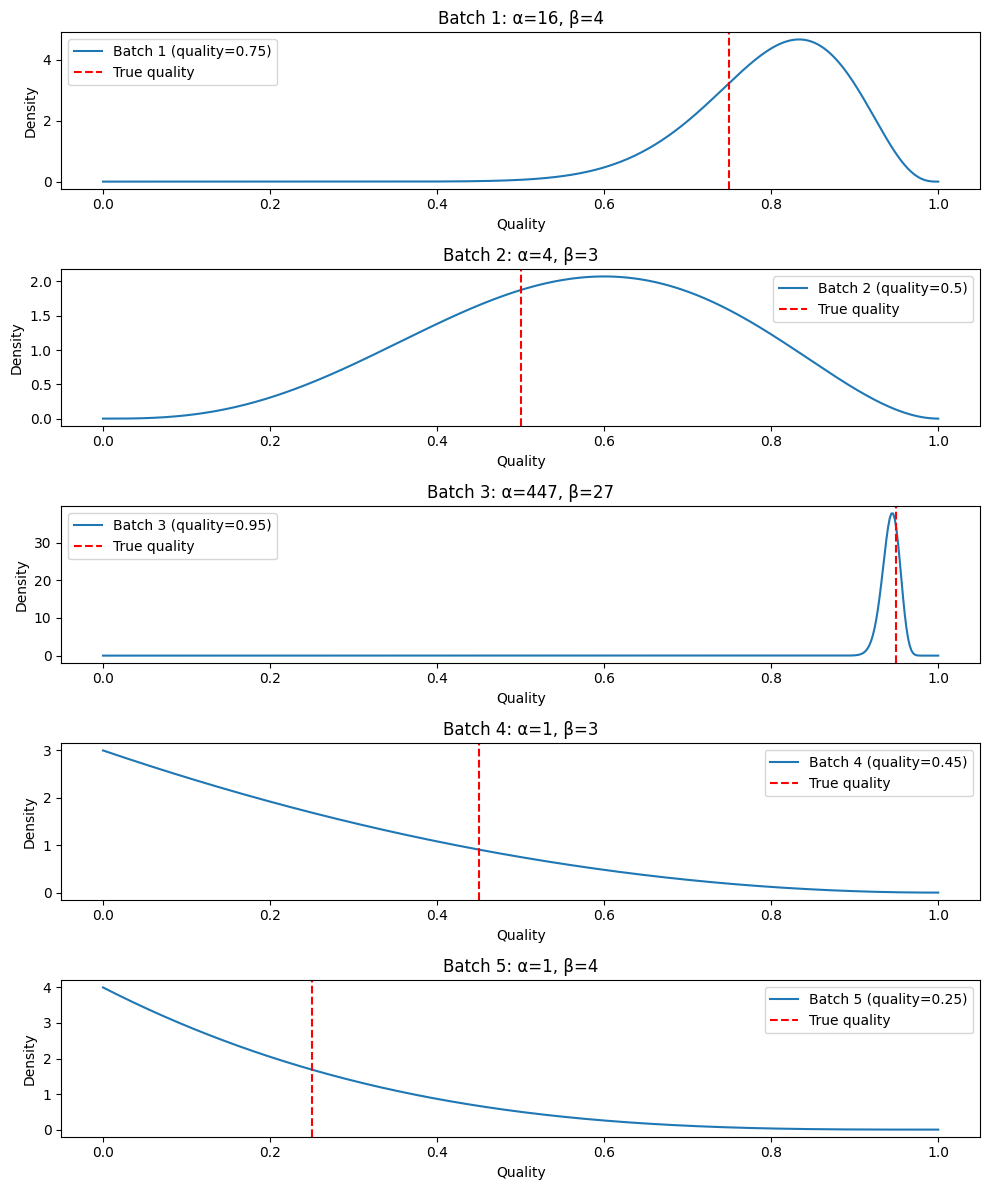

In [112]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 500

factory = Factory()
factory.set_batches(qualities)
res = {}

for step in range(STEPS):
    factory.get_element()
    res[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]

x = np.linspace(0,1,STEPS)
fig, axes = plt.subplots(BATCHES_NUM, 1, figsize=(10, 12))

for i in range(BATCHES_NUM):
    alpha_final, beta_final, quality = res[STEPS-1][i]
    y = beta.pdf(x, alpha_final, beta_final)
    axes[i].plot(x, y, label=f'Batch {i+1} (quality={quality})')
    axes[i].axvline(quality, color='r', linestyle='--', label='True quality')
    axes[i].set_title(f'Batch {i+1}: α={alpha_final}, β={beta_final}')
    axes[i].legend()
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot.

In [ ]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1
    def __init__(self, quality):
        self.quality = quality
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
class Factory:
    batches = []
    systems = 0
    good = 0

    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0
    
    def lemon_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        last_batch_idx = 0
        for step in range(steps):
            choice = last_batch_idx
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            self.systems = self.systems + 1
            self.good = self.good + int(result)
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")
            if result == False:
                last_batch_idx = last_batch_idx + 1 if last_batch_idx + 1 < self.n_batches else 0
            results.append(result)
            
        return results.count(True), batch_success, batch_total
    
    def rank_descending_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)
        
        current_step = 0
        while current_step < steps:
            means = np.array([b.alpha / (b.alpha + b.beta) for b in self.batches])
            
            order = np.argsort(-means)
            
            schedule = []
            for i, batch_idx in enumerate(order):
                count = self.n_batches - i
                schedule.extend([batch_idx] * count)
            
            for batch_idx in schedule:
                if current_step >= steps:
                    break
                
                result = self.batches[batch_idx].get_element()
                
                batch_success[batch_idx] += int(result)
                batch_total[batch_idx] += 1
                self.systems += 1
                self.good += int(result)
                results.append(result)
                
                current_step += 1
                
        return results.count(True), batch_success, batch_total
    
    def ratio_geometric_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        current_step = 0
        while current_step < steps:
            means = np.array([b.alpha / (b.alpha + b.beta) for b in self.batches])
            
            order = np.argsort(means)
            sorted_means = means[order]
            
            worst_quality = sorted_means[0]
            if worst_quality == 0: worst_quality = 0.001
            
            amounts = (sorted_means / worst_quality)
            amounts = np.maximum(1, np.round(amounts)).astype(int)

            schedule = []
            for i, batch_idx in enumerate(order):
                count = amounts[i]
                schedule.extend([batch_idx] * count)
            
            for batch_idx in schedule:
                if current_step >= steps:
                    break
                
                result = self.batches[batch_idx].get_element()
                
                batch_success[batch_idx] += int(result)
                batch_total[batch_idx] += 1
                self.systems += 1
                self.good += int(result)
                results.append(result)
                
                current_step += 1
                
        return results.count(True), batch_success, batch_total
    
    def softmax_method(self, steps, temp=0.1):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            means = np.array([b.alpha / (b.alpha + b.beta) for b in self.batches])
            
            logits = means / temp
            
            logits -= np.max(logits) 
            
            exp_logits = np.exp(logits)
            probs = exp_logits / np.sum(exp_logits)

            choice = np.random.choice(self.n_batches, p=probs)
            
            result = self.batches[choice].get_element()
            
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            self.systems += 1
            self.good += int(result)
            results.append(result)
    
        return results.count(True), batch_success, batch_total
            


In [114]:
# BATCHES_NUM = 5
qualities = [0.65, 0.70, 0.75, 0.8, 0.85]

STEPS = 100
SIM_NUMS = 1

scores = []

Lemon method:

In [115]:
lemon_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.lemon_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset()
    lemon_scores.append(results / STEPS)
    
    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(lemon_scores))
print(f"Avg. success rate: {sum(lemon_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 12 | Beta: 6
Batch 1: Alpha: 14 | Beta: 6
Batch 2: Alpha: 11 | Beta: 6
Batch 3: Alpha: 24 | Beta: 5
Batch 4: Alpha: 21 | Beta: 5
Success rate: 0.77
[11. 13. 10. 23. 20.]
[16. 18. 15. 27. 24.]
Avg. success rate: 0.77
Successful batch use:
Batch 0 (qual: 0.65): 11.0/16.0
Batch 1 (qual: 0.7): 13.0/18.0
Batch 2 (qual: 0.75): 10.0/15.0
Batch 3 (qual: 0.8): 23.0/27.0
Batch 4 (qual: 0.85): 20.0/24.0


Ranking descending method:

In [116]:
rank_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.rank_descending_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    rank_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(rank_scores))
print(f"Avg. success rate: {sum(rank_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}: {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 16 | Beta: 8
Batch 1: Alpha: 11 | Beta: 4
Batch 2: Alpha: 17 | Beta: 4
Batch 3: Alpha: 20 | Beta: 8
Batch 4: Alpha: 17 | Beta: 5
Success rate: 0.76
[15. 10. 16. 19. 16.]
[22. 13. 19. 26. 20.]
Avg. success rate: 0.76
Successful batch use:
Batch 0 (qual: 0.65: 15.0/22.0
Batch 1 (qual: 0.7: 10.0/13.0
Batch 2 (qual: 0.75: 16.0/19.0
Batch 3 (qual: 0.8: 19.0/26.0
Batch 4 (qual: 0.85: 16.0/20.0


Ratio score method:

In [117]:
ratio_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.ratio_geometric_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    ratio_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)
        
scores.append(np.average(ratio_scores))
print(f"Avg. success rate: {sum(ratio_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 16 | Beta: 6
Batch 1: Alpha: 19 | Beta: 6
Batch 2: Alpha: 7 | Beta: 8
Batch 3: Alpha: 18 | Beta: 5
Batch 4: Alpha: 24 | Beta: 1
Success rate: 0.79
[15. 18.  6. 17. 23.]
[20. 23. 13. 21. 23.]
Avg. success rate: 0.79
Successful batch use:
Batch 0 (qual: 0.65): 15.0/20.0
Batch 1 (qual: 0.7): 18.0/23.0
Batch 2 (qual: 0.75): 6.0/13.0
Batch 3 (qual: 0.8): 17.0/21.0
Batch 4 (qual: 0.85): 23.0/23.0


Own method - softmax:

In [118]:
softmax_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.softmax_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    softmax_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(softmax_scores))
print(f"Avg. success rate: {sum(softmax_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")

Batch 0: Alpha: 1 | Beta: 1
Batch 1: Alpha: 2 | Beta: 2
Batch 2: Alpha: 8 | Beta: 2
Batch 3: Alpha: 31 | Beta: 3
Batch 4: Alpha: 50 | Beta: 10
Success rate: 0.87
[ 0.  1.  7. 30. 49.]
[ 0.  2.  8. 32. 58.]
Avg. success rate: 0.87
Successful batch use:
Batch 0 (qual: 0.65): 0.0/0.0
Batch 1 (qual: 0.7): 1.0/2.0
Batch 2 (qual: 0.75): 7.0/8.0
Batch 3 (qual: 0.8): 30.0/32.0
Batch 4 (qual: 0.85): 49.0/58.0


[np.float64(0.77), np.float64(0.76), np.float64(0.79), np.float64(0.87)]


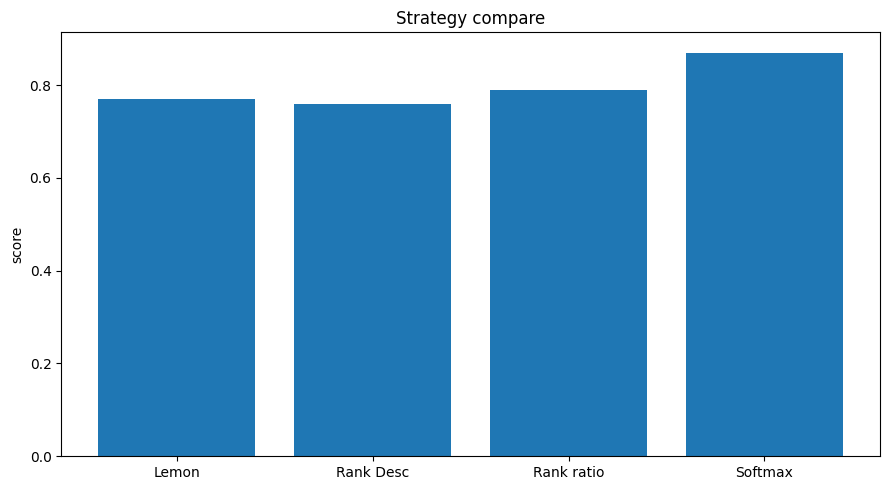

In [119]:
names = ["Lemon", "Rank Desc", "Rank ratio", "Softmax"]
print(scores)
plt.figure(figsize=(9,5))
plt.bar(names, scores)
plt.ylabel("score")
plt.title("Strategy compare")
plt.tight_layout()
plt.show()

3. In real life it is possible that the quality of components from a manufacture changes in time. 
Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the 
learned parameters of Beta distribution for each batch. Check using an appropriate example.

In [120]:
class BatchWithMemory:
    quality = 0.5
    alpha = 1
    beta = 1
    
    def __init__(self, quality, decay_rate=0.99):
        self.quality = quality
        self.decay_rate = decay_rate
        self.initial_alpha = 1
        self.initial_beta = 1
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
    def apply_memory_decay(self):
        self.alpha = self.decay_rate * self.alpha + (1 - self.decay_rate) * self.initial_alpha
        self.beta = self.decay_rate * self.beta + (1 - self.decay_rate) * self.initial_beta
    
    def change_quality(self, new_quality):
        self.quality = new_quality


class FactoryWithMemory:
    batches = []
    systems = 0
    good = 0
    
    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities, decay_rate=0.9):
        self.batches = [BatchWithMemory(quality, decay_rate) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0
    
    def thompson_sampling_method(self, steps, decay_interval=10, quality_changes=None):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)
        
        history = {i: {'alpha': [], 'beta': [], 'quality': []} for i in range(self.n_batches)}
        
        for step in range(steps):
            if quality_changes and step in quality_changes:
                for batch_idx, new_quality in quality_changes[step].items():
                    self.batches[batch_idx].change_quality(new_quality)
                    print(f"Step {step}: Batch {batch_idx} quality changed to {new_quality}")
            
            samples = [batch.sample_distribution() for batch in self.batches]
            choice = np.argmax(samples)
            
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            for i, b in enumerate(self.batches):
                history[i]['alpha'].append(b.alpha)
                history[i]['beta'].append(b.beta)
                history[i]['quality'].append(b.quality)
            
            if (step + 1) % decay_interval == 0:
                for batch in self.batches:
                    batch.apply_memory_decay()
            
            self.systems += 1
            self.good += int(result)
            results.append(result)
        
        return results, batch_success, batch_total, history

Step 2500: Batch 0 quality changed to 0.7
Step 2500: Batch 1 quality changed to 0.8
Step 2500: Batch 2 quality changed to 0.7
Step 2500: Batch 3 quality changed to 0.85
Step 2500: Batch 4 quality changed to 0.9
Step 5000: Batch 0 quality changed to 0.75
Step 5000: Batch 1 quality changed to 0.75
Step 5000: Batch 2 quality changed to 0.7
Step 5000: Batch 3 quality changed to 0.85
Step 5000: Batch 4 quality changed to 0.9
Step 7500: Batch 0 quality changed to 0.8
Step 7500: Batch 1 quality changed to 0.7
Step 7500: Batch 2 quality changed to 0.7
Step 7500: Batch 3 quality changed to 0.9
Step 7500: Batch 4 quality changed to 0.95
Batch 0: Alpha: 6.44 | Beta: 1.86
Batch 1: Alpha: 1.23 | Beta: 1.31
Batch 2: Alpha: 5.45 | Beta: 1.90
Batch 3: Alpha: 6.22 | Beta: 1.85
Batch 4: Alpha: 29.76 | Beta: 2.97
Success rate: 0.8488
Batch successes: [ 698.  693.  621. 1882. 4594.]
Batch totals: [ 934.  942.  853. 2201. 5070.]

Avg. success rate: 0.8488

Batch usage:
  Batch 0 (qual: 0.65 -> 0.7 -> 0.75 

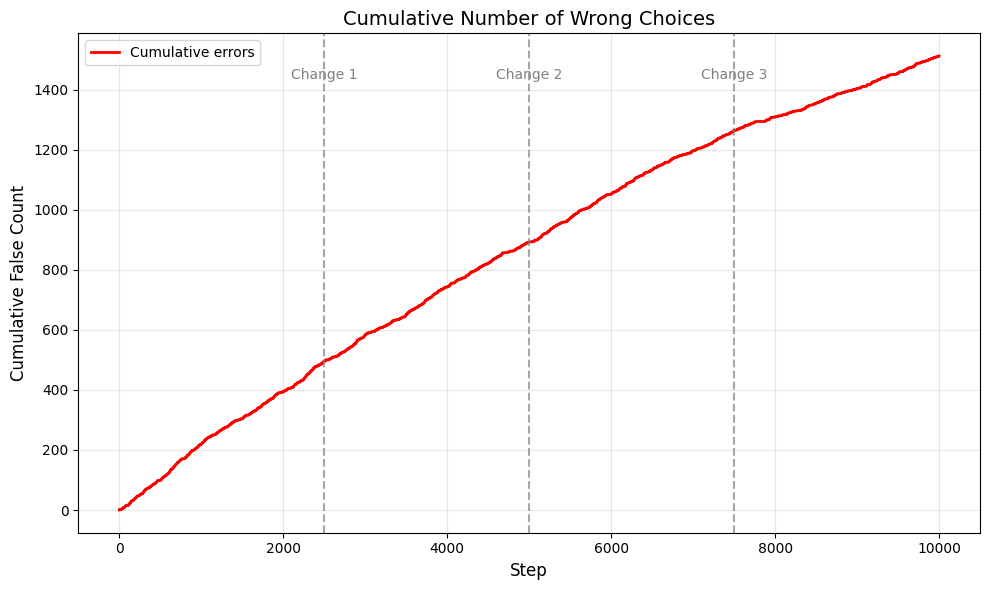

In [121]:
init_qualities = [0.65, 0.7, 0.75, 0.8, 0.85]
thompson_scores = []

STEPS = 10000
DECAY_INTERVAL = 1
DECAY_RATE = 0.98

quality_changes = {
    2500: {
        0: 0.70,
        1: 0.80,
        2: 0.70,  
        3: 0.85,
        4: 0.90   
    },
    5000: {
        0: 0.75,
        1: 0.75,
        2: 0.70,
        3: 0.85,
        4: 0.90,
    },
    7500: {
        0: 0.80,
        1: 0.70,
        2: 0.70,
        3: 0.90,
        4: 0.95,
    }
}

for _ in range(SIM_NUMS):
    factory = FactoryWithMemory()
    factory.set_batches(init_qualities.copy(), decay_rate=DECAY_RATE)

    results, batch_success, batch_total, history = factory.thompson_sampling_method(
        STEPS, 
        decay_interval=DECAY_INTERVAL,
        quality_changes=quality_changes
    )
    
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha:.2f} | Beta: {b.beta:.2f}")
    factory.reset() 
    thompson_scores.append(results.count(True) / STEPS)

    if _ < 1:
        print(f"Success rate: {results.count(True) / STEPS:.4f}")
        print(f"Batch successes: {batch_success}")
        print(f"Batch totals: {batch_total}")

print(f"\nAvg. success rate: {sum(thompson_scores) / SIM_NUMS:.4f}")
print("\nBatch usage:")
for i in range(len(init_qualities)):
    print(f"  Batch {i} (qual: {init_qualities[i]} -> {quality_changes[2500][i]} -> {quality_changes[5000][i]} -> {quality_changes[7500][i]}): {batch_total[i]:.0f} times ({batch_total[i]/STEPS*100:.1f}%)")

cumulative_false = []
false_count = 0
for value in results:
    if value == False:
        false_count += 1
    cumulative_false.append(false_count)

window_size = 50
error_rate = []
for i in range(STEPS):
    start = max(0, i - window_size + 1)
    window = results[start:i+1]
    error_rate.append(window.count(False) / len(window))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))  

ax.plot(range(STEPS), cumulative_false, linewidth=2, color='red', label='Cumulative errors')

ax.axvline(x=2500, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axvline(x=5000, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)
ax.axvline(x=7500, color='gray', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(2500, max(cumulative_false)*0.95, 'Change 1', ha='center', fontsize=10, color='gray')
ax.text(5000, max(cumulative_false)*0.95, 'Change 2', ha='center', fontsize=10, color='gray')
ax.text(7500, max(cumulative_false)*0.95, 'Change 3', ha='center', fontsize=10, color='gray')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Cumulative False Count', fontsize=12)
ax.set_title('Cumulative Number of Wrong Choices', fontsize=14)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()